In [1]:
# import lib 
import pandas as pd 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,precision_score,recall_score,accuracy_score
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv("indian_bikes_dataset_1000.csv")
data

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,buyer_behaviour,price_sensitivity
0,Honda,Hornet 2.0,184,mid,2020,Digital,137,43.8,10.1,100781,28.0,28219,129000,147604,70,9.3,Will likely switch brand,High
1,Bajaj,Pulsar N250,249,mid,2024,Digital,157,33.2,14.9,123438,28.0,34562,158000,185890,71,4.1,Might reconsider,Medium
2,Hero,Splendor Plus,97,budget,2020,Analog,95,64.2,8.7,60156,28.0,16844,77000,89751,57,2.3,Might reconsider,Medium
3,Royal Enfield,Thunderbird 350X,346,premium,2025,Semi-Digital,152,29.1,17.3,146875,28.0,41125,188000,221689,67,8.7,Will likely switch brand,High
4,Royal Enfield,Scram 411,411,premium,2023,Semi-Digital,165,23.4,14.9,166412,31.0,51588,218000,251257,73,13.1,Will definitely switch,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Yamaha,R3,321,premium,2020,Digital,144,33.6,15.0,360938,28.0,101062,462000,530814,73,7.0,Will likely switch brand,High
996,Hero,Super Splendor,125,budget,2022,Semi-Digital,117,53.5,12.4,70312,28.0,19688,90000,107247,59,13.5,Will definitely switch,Very High
997,Bajaj,Platina 110 H-Gear,115,budget,2024,Semi-Digital,111,50.2,10.8,63281,28.0,17719,81000,97000,61,2.9,Might reconsider,Medium
998,TVS,Ronin,225,mid,2024,Digital,165,29.6,16.1,120312,28.0,33688,154000,180601,70,2.3,Might reconsider,Medium


<Axes: xlabel='brand', ylabel='on_road_price_inr'>

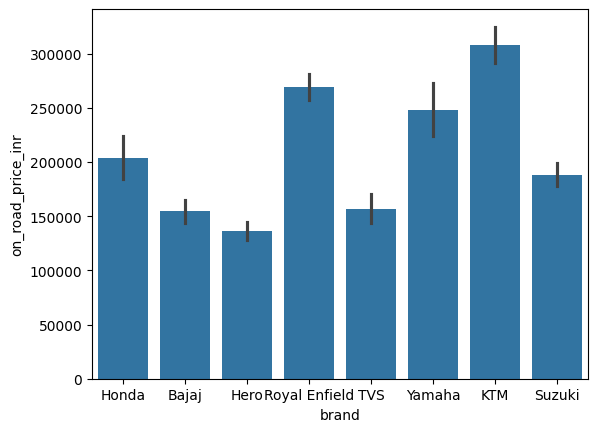

In [4]:
sns.barplot(x= data["brand"] ,y = data["on_road_price_inr"])

In [5]:
data = pd.get_dummies(data, drop_first=True)
data

,cc,year,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,...,segment_premium,speedometer_type_Digital,speedometer_type_Semi-Digital,buyer_behaviour_Might reconsider,buyer_behaviour_Will definitely switch,buyer_behaviour_Will likely switch brand,buyer_behaviour_Will still buy,price_sensitivity_Low,price_sensitivity_Medium,price_sensitivity_Very High
0,184,2020,137,43.8,10.1,100781,28.0,28219,129000,147604,...,False,True,False,False,False,True,False,False,False,False
1,249,2024,157,33.2,14.9,123438,28.0,34562,158000,185890,...,False,True,False,True,False,False,False,False,True,False
2,97,2020,95,64.2,8.7,60156,28.0,16844,77000,89751,...,False,False,False,True,False,False,False,False,True,False
3,346,2025,152,29.1,17.3,146875,28.0,41125,188000,221689,...,True,False,True,False,False,True,False,False,False,False
4,411,2023,165,23.4,14.9,166412,31.0,51588,218000,251257,...,True,False,True,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,321,2020,144,33.6,15.0,360938,28.0,101062,462000,530814,...,True,True,False,False,False,True,False,False,False,False
996,125,2022,117,53.5,12.4,70312,28.0,19688,90000,107247,...,False,False,True,False,True,False,False,False,False,True
997,115,2024,111,50.2,10.8,63281,28.0,17719,81000,97000,...,False,False,True,True,False,False,False,False,True,False
998,225,2024,165,29.6,16.1,120312,28.0,33688,154000,180601,...,False,True,False,True,False,False,False,False,True,False


In [6]:
X =data.drop(columns=[
    "on_road_price_inr",
    "factory_price_inr",
    "gst_amount_inr",
    "ex_showroom_inr"
])
Y =data["on_road_price_inr"]
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.2,random_state = 42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
model = LinearRegression()
model.fit(X_train_scaled,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
Y_pred = model.predict(X_test_scaled)
print("prediction:",Y_pred)

prediction: [109108.28501462 201101.27798782 197229.49473551 231740.95357855
 332059.00158504 197011.04218255 155794.35324401 150034.54661806
 167221.98238756 280778.23145078 388917.44036663 159813.79195831
 254341.46250166  79121.90138494 234397.02522325  91405.1277024
 322563.14195191 141602.47031671 153176.86113951 194123.06624031
  82564.81588569 243229.75645195 151824.12357502 159213.63430515
 153158.02282971 241925.87400279 140813.86570495 171816.48788134
 161471.19634197 329906.21427218 149923.38695825 520788.67659436
 115589.12965492 505469.06150841 214011.0677799  359891.49347329
 150187.27312477 114499.99794355 199013.63851076 388767.9204584
 154571.60563185 185428.60013594 112565.16032156 330211.12793919
 223321.87576715 191021.52061727 387635.92393687 424028.16051821
 646469.22476763 200204.55773896 195572.23197466 388777.3524579
 323165.56406977 360986.71799044 192185.86283548  93395.41798305
 158948.48409091 158566.15184094 188848.40011875 174247.80907136
 382078.42176101

In [9]:
#evalutuon 

print("R2 score :",r2_score(Y_test,Y_pred)*100,"%")


R2 score : 98.72372349121848 %


In [10]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(Y_test, Y_pred))

8782.833506553481


In [10]:
from sklearn.linear_model import Lasso

model = Lasso()

model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

print(r2_score(Y_test, Y_pred))

0.9872214209952533


C:\Users\AAYUSH\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.056e+10, tolerance: 9.031e+08
  model = cd_fast.enet_coordinate_descent(
